In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
import QwaveMPS as qmps


<h1> Tests with QWaveMPS </h1>

In [2]:
""""Choose the simulation parameters"""
#Choose the bins:
# Dimension chosen to be 2 to as TLS only results in emission in single quanta subspace per unit time
d_t_l=2 #Time right channel bin dimension
d_t_r=2 #Time left channel bin dimension
d_t_total=np.array([d_t_l,d_t_r])

d_sys1=2 # tls bin dimension
d_sys_total=np.array([d_sys1]) #total system bin (in this case only 1 tls)

#Choose the coupling:
gamma_l,gamma_r=qmps.coupling('symmetrical',gamma=1)

#Define input parameters
input_params = qmps.parameters.InputParams(
    delta_t=0.02,
    tmax = 35, # Long max time to reach steady state
    d_sys_total=d_sys_total,
    d_t_total=d_t_total,
    gamma_l=gamma_l,
    gamma_r = gamma_r,
    bond_max=18
)

#Make a tlist for plots:
tmax=input_params.tmax
delta_t=input_params.delta_t
tlist=np.arange(0,tmax+(delta_t/2),delta_t)

In [66]:
""" Choose the initial state"""
sys_initial_state=qmps.states.tls_ground()

env = qmps.states.gaussian_envelope(
    pulse_time=1,
    params=input_params,
    gaussian_width=2,
    gaussian_center=30
)

wg_initial_state = qmps.states.fock_pulse(
    env,
    pulse_time=20,
    photon_num=1,
    params=input_params,
    direction='R'
)

"""Choose the Hamiltonian"""
#CW Drive
cw_pump=0

# Hamiltonian is 1TLS pumped (from above) by CW
Hm=qmps.hamiltonians.hamiltonian_1tls(input_params,cw_pump)

In [67]:
"""Calculate time evolution of the system"""
bins = qmps.simulation.t_evol_mar(Hm,sys_initial_state,wg_initial_state,input_params)

In [68]:
"""Define relevant photonic operators"""
tls_pop_op = qmps.tls_pop()
flux_pop_l = qmps.b_dag_l(input_params) @ qmps.b_l(input_params)
flux_pop_r = qmps.b_dag_r(input_params) @ qmps.b_r(input_params)
photon_pop_ops = [flux_pop_l, flux_pop_r]

"""Calculate population dynamics"""
tls_pop = qmps.single_time_expectation(bins.system_states,qmps.tls_pop())
photon_fluxes = qmps.single_time_expectation(bins.output_field_states, photon_pop_ops)

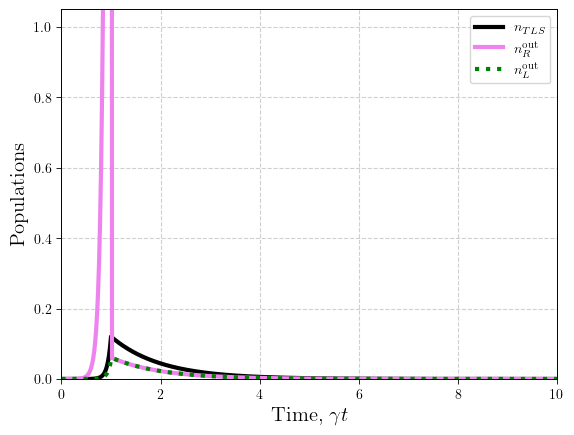

In [69]:
fonts=15

plt.plot(tlist,np.real(tls_pop),linewidth = 3, color = 'k',linestyle='-',label=r'$n_{TLS}$') # TLS population
plt.plot(tlist,np.real(photon_fluxes[1]),linewidth = 3,color = 'violet',linestyle='-',label=r'$n^{\rm out}_{R}$') # Photon flux transmitted to the right channel
plt.plot(tlist,np.real(photon_fluxes[0]),linewidth = 3,color = 'green',linestyle=':',label=r'$n^{\rm out}_{L}$') # Photon flux transmitted to the left channel
plt.legend()
plt.xlabel(r'Time, $\gamma t$',fontsize=fonts)
plt.ylabel('Populations',fontsize=fonts)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim([0.,1.05])
plt.xlim([0.,10])
plt.show()